# Lab 02 - Data Understanding: AI Workforce Displacement 2020-2026

This notebook applies **Lab 2 - Data Understanding** to the assignment dataset. The goal is to become familiar with the data through dataframe inspection, category counts, and visual exploration.


## Lab 2 concepts used

- Import pandas, seaborn, matplotlib, and warnings.
- Use `head()` and `tail()` to inspect rows.
- Use `value_counts()` to understand important categories or labels.
- Create scatter, jointplot, hue-based scatter, boxplot, stripplot, KDE, pairplot, grouped boxplot, and radviz visualizations where suitable for the dataset.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'AML Assignment' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT


WindowsPath('D:/APU Study/1st Semester/Applied Machine Learning/AML Assignment')

In [3]:
DATASET_FILENAME = 'ai_workforce_displacement_global_2020_2026.csv'
matches = sorted((PROJECT_ROOT / 'Datasets').glob(f'*/{DATASET_FILENAME}'))
if not matches:
    raise FileNotFoundError(f'Could not find {DATASET_FILENAME} under {PROJECT_ROOT / "Datasets"}')
DATASET_PATH = matches[0]
data = pd.read_csv(DATASET_PATH)
data.head()


,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202,Research-calibrated synthetic data. Grounded i...
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655,Research-calibrated synthetic data. Grounded i...
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542,Research-calibrated synthetic data. Grounded i...


In [4]:
data.tail()


,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
20795,20796,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Education & Research,0.308,...,0.0056,-0.0162,29,0.450,0.58,0.651,16,3.5,0.184,Research-calibrated synthetic data. Grounded i...
20796,20797,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Transportation & Logistics,0.675,...,0.0205,-0.0329,126,0.476,0.22,0.235,15,4.2,0.457,Research-calibrated synthetic data. Grounded i...
20797,20798,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Media & Communications,0.516,...,0.0154,-0.0351,131,0.446,0.46,0.482,17,4.3,0.419,Research-calibrated synthetic data. Grounded i...
20798,20799,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Administrative & Clerical,0.801,...,0.0260,-0.0654,476,0.499,0.79,0.950,14,4.2,0.459,Research-calibrated synthetic data. Grounded i...
20799,20800,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Energy & Utilities,0.440,...,0.0160,-0.0216,67,0.490,0.26,0.270,12,4.1,0.377,Research-calibrated synthetic data. Grounded i...


In [5]:
print('Shape:', data.shape)
print('Columns:')
for column in data.columns:
    print('-', column)


Shape: (20800, 23)
Columns:
- record_id
- country
- iso3_code
- region
- income_group
- year
- quarter
- quarter_label
- industry_sector
- sector_automation_risk_score
- gdp_per_capita_usd
- ai_adoption_index
- pct_sector_workforce_displaced
- pct_sector_workforce_new_roles_created
- net_workforce_change_pct
- ai_cited_layoff_announcements
- ai_skill_wage_premium_pct
- pct_workforce_female
- pct_displaced_roles_female
- reskilling_programs_count
- govt_ai_policy_score_1_to_10
- ai_tool_adoption_pct
- data_source_notes


In [6]:
print('\nValue counts for region')
display(data['region'].value_counts(dropna=False).head(15))

print('\nValue counts for income_group')
display(data['income_group'].value_counts(dropna=False).head(15))

print('\nValue counts for industry_sector')
display(data['industry_sector'].value_counts(dropna=False).head(15))



Value counts for region


region
Europe                5200
Latin America         3380
Africa                3380
Southeast Asia        2080
Middle East           1820
East Asia             1300
South Asia            1300
North America          520
Oceania                520
Europe/Asia            520
Central Asia           520
Middle East/Africa     260
Name: count, dtype: int64


Value counts for income_group


income_group
High Income            8060
Lower Middle Income    6240
Upper Middle Income    5720
Low Income              780
Name: count, dtype: int64


Value counts for industry_sector


industry_sector
Technology & Software         2080
Finance & Banking             2080
Healthcare & Life Sciences    2080
Manufacturing & Industry      2080
Retail & E-Commerce           2080
Education & Research          2080
Transportation & Logistics    2080
Media & Communications        2080
Administrative & Clerical     2080
Energy & Utilities            2080
Name: count, dtype: int64

## Dataset-adapted Lab 2 visualizations

The original Lab 2 notebook uses Iris features such as sepal length, sepal width, petal length, and species. The cells below keep the same visualization ideas, but use columns that make sense for this dataset.


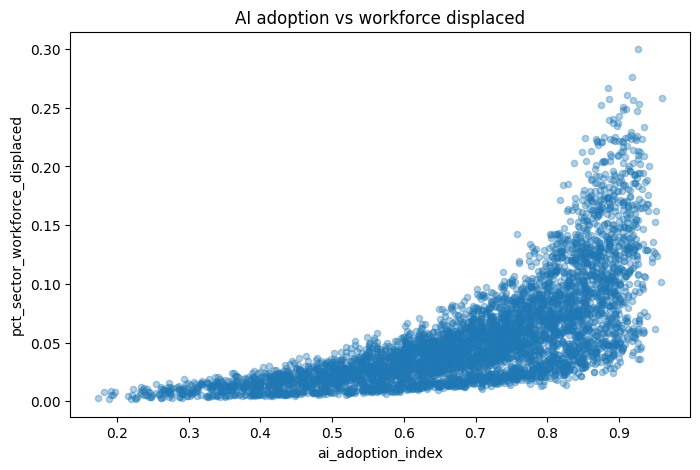

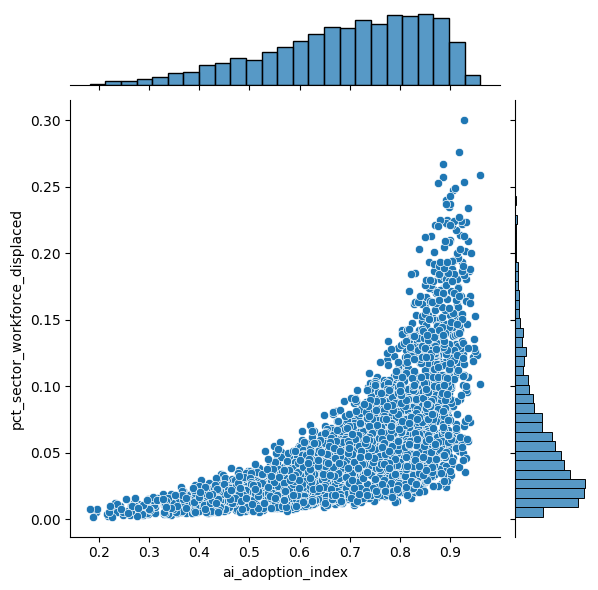

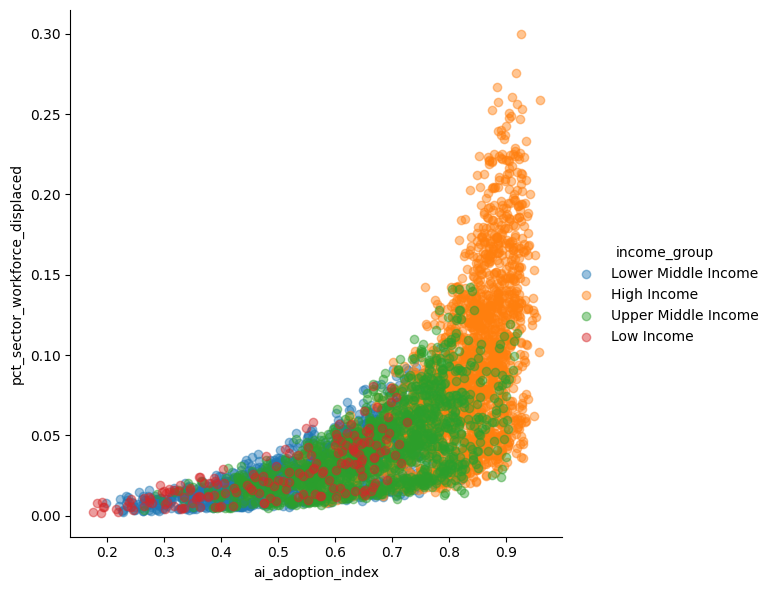

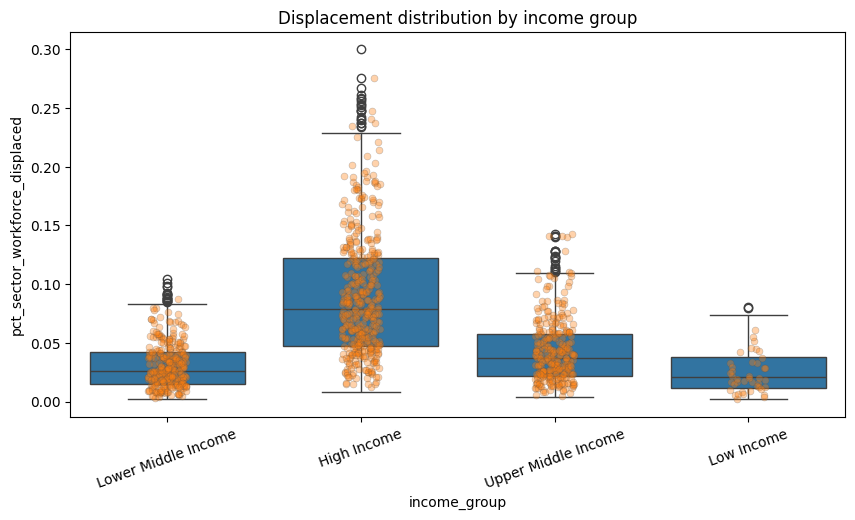

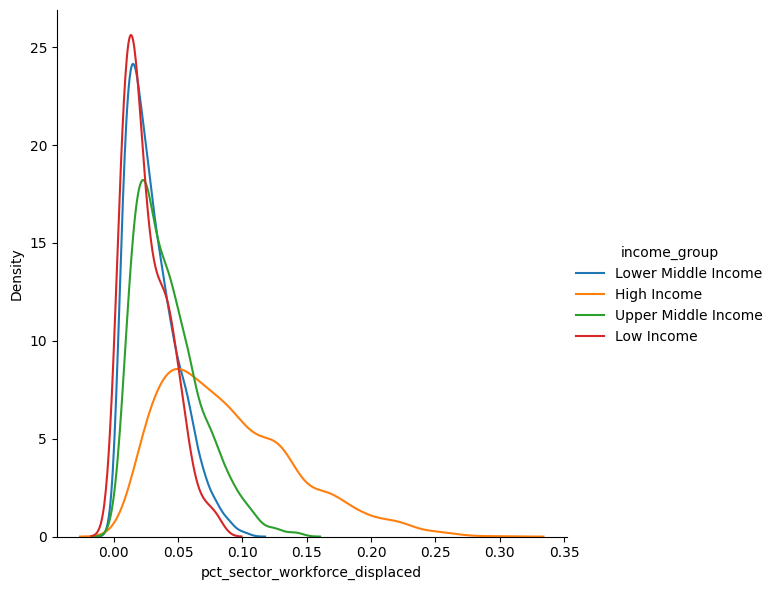

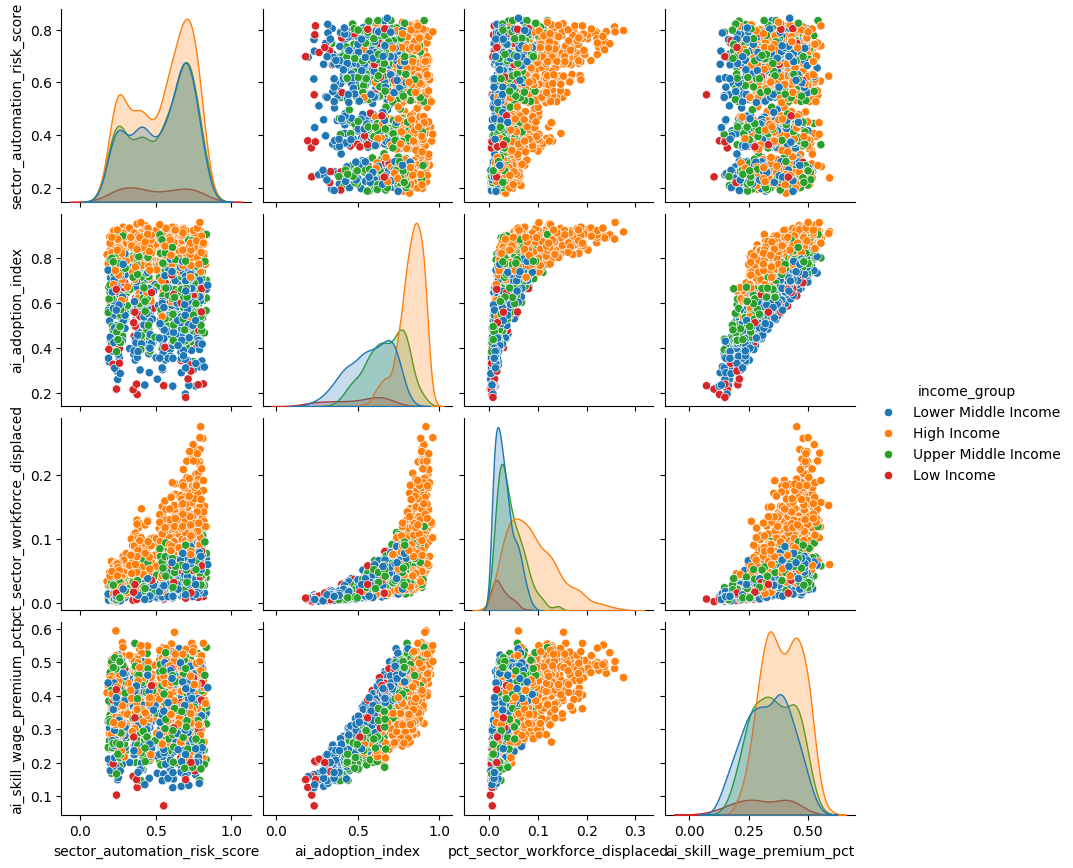

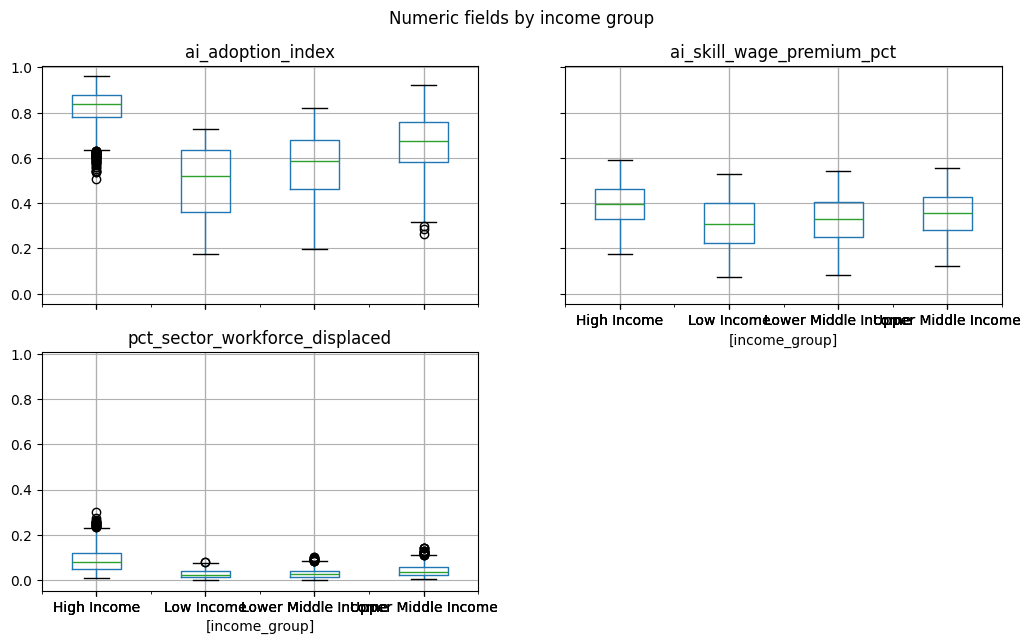

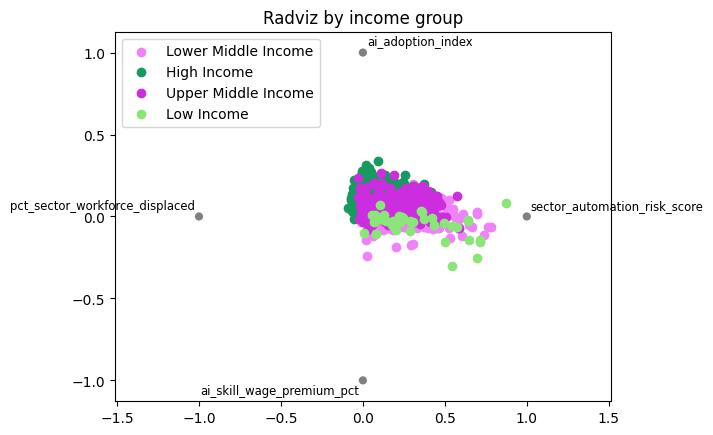

In [7]:
plot_df = data.sample(n=min(5000, len(data)), random_state=42)
plot_df.plot(kind='scatter', x='ai_adoption_index', y='pct_sector_workforce_displaced', alpha=0.35, figsize=(8, 5), title='AI adoption vs workforce displaced')
plt.show()

sns.jointplot(x='ai_adoption_index', y='pct_sector_workforce_displaced', data=plot_df.sample(n=min(3000, len(plot_df)), random_state=42), height=6)
plt.show()

sns.FacetGrid(plot_df, hue='income_group', height=6).map(plt.scatter, 'ai_adoption_index', 'pct_sector_workforce_displaced', alpha=0.45).add_legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='income_group', y='pct_sector_workforce_displaced', data=plot_df)
sns.stripplot(x='income_group', y='pct_sector_workforce_displaced', data=plot_df.sample(n=min(1000, len(plot_df)), random_state=42), jitter=True, edgecolor='gray', linewidth=0.4, alpha=0.35)
plt.title('Displacement distribution by income group')
plt.xticks(rotation=20)
plt.show()

sns.FacetGrid(plot_df, hue='income_group', height=6).map(sns.kdeplot, 'pct_sector_workforce_displaced').add_legend()
plt.show()

pair_cols = ['sector_automation_risk_score', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'ai_skill_wage_premium_pct', 'income_group']
sns.pairplot(plot_df[pair_cols].dropna().sample(n=min(1500, len(plot_df)), random_state=42), hue='income_group', height=2.2, diag_kind='kde')
plt.show()

box_cols = ['income_group', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'ai_skill_wage_premium_pct']
plot_df[box_cols].boxplot(by='income_group', figsize=(12, 7))
plt.suptitle('Numeric fields by income group')
plt.show()

from pandas.plotting import radviz
radviz_cols = ['sector_automation_risk_score', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'ai_skill_wage_premium_pct', 'income_group']
radviz(plot_df[radviz_cols].dropna().sample(n=min(1000, len(plot_df)), random_state=42), 'income_group')
plt.title('Radviz by income group')
plt.show()


## What was learned from Lab 2

These plots give an initial view of distributions, category balance, relationships between numeric fields, and possible separation by important labels or groups. No preprocessing or machine learning model is applied yet; that begins from Lab 3 onward.
